In [176]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [177]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [179]:
#df = pd.read_csv('data_set_3.csv')
df = pd.read_csv('dataset.csv')
print(df.head())

   market_id           created_at actual_delivery_time  \
0        1.0  2015-02-06 22:24:17  2015-02-06 23:27:16   
1        2.0  2015-02-10 21:49:25  2015-02-10 22:56:29   
2        3.0  2015-01-22 20:39:28  2015-01-22 21:09:09   
3        3.0  2015-02-03 21:21:45  2015-02-03 22:13:00   
4        3.0  2015-02-15 02:40:36  2015-02-15 03:20:26   

                           store_id store_primary_category  order_protocol  \
0  df263d996281d984952c07998dc54358               american             1.0   
1  f0ade77b43923b38237db569b016ba25                mexican             2.0   
2  f0ade77b43923b38237db569b016ba25                    NaN             1.0   
3  f0ade77b43923b38237db569b016ba25                    NaN             1.0   
4  f0ade77b43923b38237db569b016ba25                    NaN             1.0   

   total_items  subtotal  num_distinct_items  min_item_price  max_item_price  \
0            4      3441                   4             557            1239   
1            1      19

In [180]:
df.columns

Index(['market_id', 'created_at', 'actual_delivery_time', 'store_id',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_partners', 'total_busy_partners',
       'total_outstanding_orders'],
      dtype='object')

In [181]:
df.shape

(197428, 14)

In [182]:
df.isnull().sum()

market_id                     987
created_at                      0
actual_delivery_time            7
store_id                        0
store_primary_category       4760
order_protocol                995
total_items                     0
subtotal                        0
num_distinct_items              0
min_item_price                  0
max_item_price                  0
total_onshift_partners      16262
total_busy_partners         16262
total_outstanding_orders    16262
dtype: int64

In [183]:

def remove_special_chars(df, cols):
    for col in cols:
        df[col] = df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True)
    return df

def safe_numeric(df, cols):
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df
def handle_infinity(df):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df

# 2. SIRF IN COLUMNS PE LAGANA HAI (Date aur Category ko chhod ke)
my_numeric_cols = [
    'total_items', 'subtotal', 'num_distinct_items', 
    'min_item_price', 'max_item_price', 
    'total_onshift_partners', 'total_busy_partners', 
    'total_outstanding_orders'
]

# 3. Data pe run karo
print("Cleaning data...")
df = remove_special_chars(df, my_numeric_cols)
df = safe_numeric(df, my_numeric_cols)
df = handle_infinity(df)   
#df[my_numeric_cols] = df[my_numeric_cols].fillna(0)
# 4. Check karo result
print(df[my_numeric_cols].dtypes) 
print(df.isnull().sum()) 

Cleaning data...
total_items                   int64
subtotal                      int64
num_distinct_items            int64
min_item_price                int64
max_item_price                int64
total_onshift_partners      float64
total_busy_partners         float64
total_outstanding_orders    float64
dtype: object
market_id                     987
created_at                      0
actual_delivery_time            7
store_id                        0
store_primary_category       4760
order_protocol                995
total_items                     0
subtotal                        0
num_distinct_items              0
min_item_price                  0
max_item_price                  0
total_onshift_partners      16262
total_busy_partners         16262
total_outstanding_orders    16262
dtype: int64


In [184]:
#print(df['subtotal'].head())
#print(df['total_items'].head())
#print(df['num_distinct_items'].head())

In [185]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime (df['actual_delivery_time'])
df['delivery_time'] = ((df['actual_delivery_time'] - df['created_at']).dt.total_seconds()/60).round(2)

In [186]:
df['order_hour'] = df['created_at'].dt.hour
df['order_day'] = df['created_at'].dt.dayofweek
df['is_weekend'] = df['order_day'].apply(lambda x: 1 if x>=5 else 0)

In [187]:
df = df.drop_duplicates()
df.duplicated().sum()
# Check karo koi duplicate rows hai ya nahi
# df.duplicated().sum()

np.int64(0)

In [188]:
df = df.dropna(subset=['actual_delivery_time'])
#df.isnull().sum()

In [189]:
df['total_onshift_partners']=df['total_onshift_partners'].fillna(df['total_onshift_partners'].median())
df['total_busy_partners']=df['total_busy_partners'].fillna(df['total_busy_partners'].median())
df['total_outstanding_orders']=df['total_outstanding_orders'].fillna(df['total_outstanding_orders'].median())  
df['store_primary_category']=df['store_primary_category'].fillna("unknown")
df['order_protocol']=df['order_protocol'].fillna(df['order_protocol'].mode()[0])
# df['order_protocol']
df['market_id']=df['market_id'].fillna(df['market_id'].mode()[0])
# df['num_distinct_items']=df['num_distinct_items'].fillna(0)
# df['max_item_price']=df['max_item_price'].fillna(0)

In [190]:
df.isnull().sum()

market_id                   0
created_at                  0
actual_delivery_time        0
store_id                    0
store_primary_category      0
order_protocol              0
total_items                 0
subtotal                    0
num_distinct_items          0
min_item_price              0
max_item_price              0
total_onshift_partners      0
total_busy_partners         0
total_outstanding_orders    0
delivery_time               0
order_hour                  0
order_day                   0
is_weekend                  0
dtype: int64

In [191]:
df.drop(columns=['created_at','actual_delivery_time','store_id'],inplace=True)

<Axes: xlabel='delivery_time'>

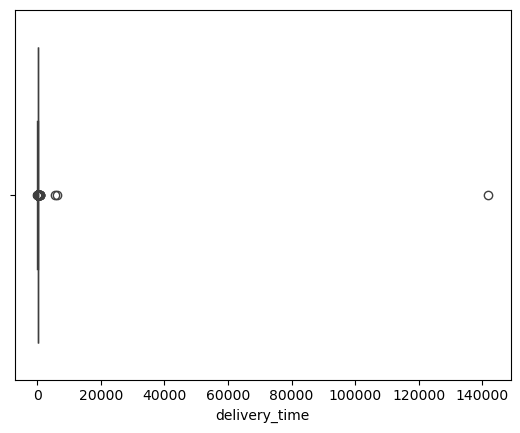

In [192]:
sns.boxplot(x=df['delivery_time'])
# befor delivery time box plot 

In [193]:
cols = ['total_items','subtotal','num_distinct_items','min_item_price','max_item_price','total_onshift_partners','total_busy_partners','total_outstanding_orders','order_hour','order_day','is_weekend']

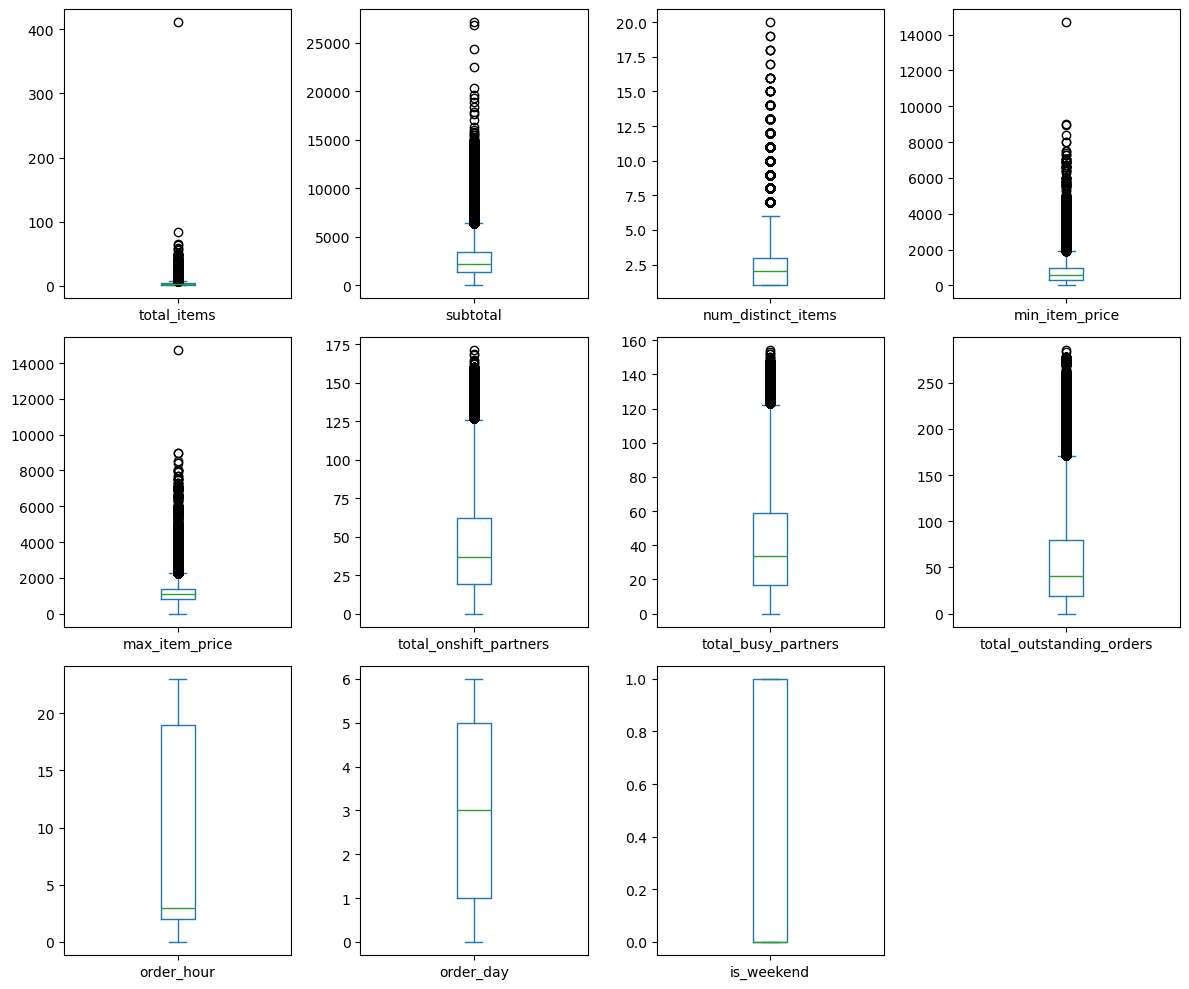

In [194]:
# before boxplot of  feature's columns
df[cols].plot(kind='box', subplots=True, layout=(3,4), figsize=(12,10))
plt.tight_layout()
plt.show()

In [195]:
for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    iqr = Q3-Q1

    lower = Q1 - 1.5 * iqr
    upper = Q3 + 1.5 * iqr

    outliers = df[(df[col] < lower ) | (df[col] > upper)]

    print(col, "outliers:", outliers.shape[0])

    df[col] = df[col].clip(lower, upper) 
    # print("After:")
    # print(df[col].describe())
    # print("----------------------")
    



total_items outliers: 9587
subtotal outliers: 9054
num_distinct_items outliers: 5919
min_item_price outliers: 4600
max_item_price outliers: 7729
total_onshift_partners outliers: 4660
total_busy_partners outliers: 2877
total_outstanding_orders outliers: 8505
order_hour outliers: 0
order_day outliers: 0
is_weekend outliers: 0


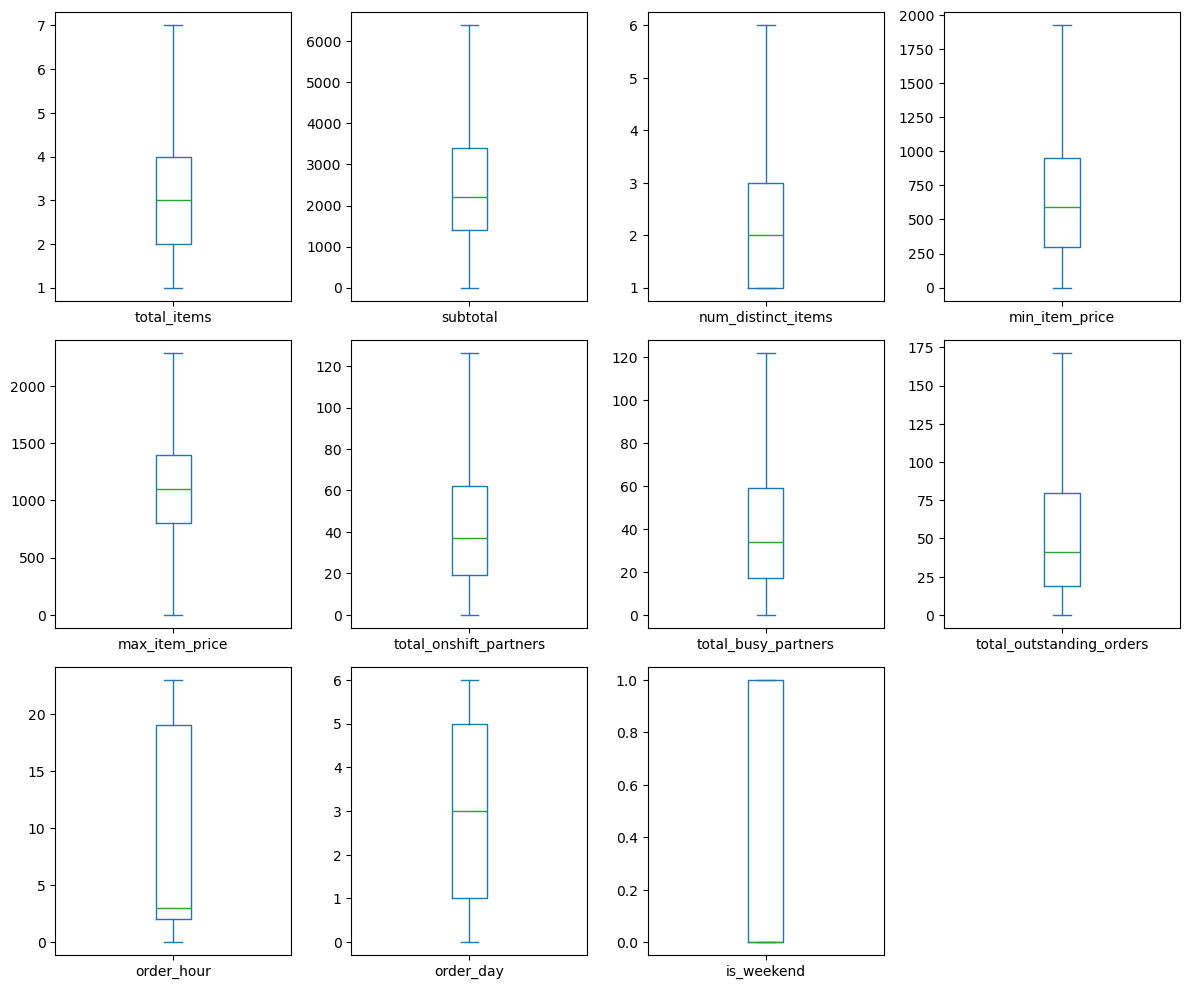

In [196]:
df[cols].plot(kind='box', subplots=True, layout=(3,4), figsize=(12,10))
plt.tight_layout()
plt.show()

In [197]:
Q1 = df['delivery_time'].quantile(0.25)
Q3 = df['delivery_time'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['delivery_time'] = df['delivery_time'].clip(lower, upper)


In [198]:
df['delivery_time'].describe()

count    197421.000000
mean         47.046184
std          16.332000
min           3.150000
25%          35.070000
50%          44.330000
75%          56.350000
max          88.270000
Name: delivery_time, dtype: float64

<Axes: xlabel='delivery_time'>

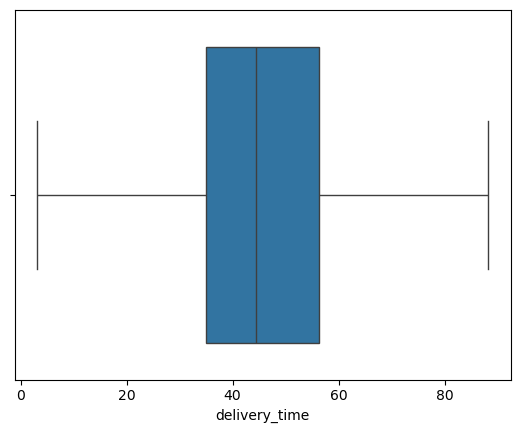

In [199]:
#Outlier after in delivery time
sns.boxplot(x=df['delivery_time'])

In [200]:
#Label Encoding
le = LabelEncoder()
cat_cols = ['market_id','order_protocol','store_primary_category']
for col in cat_cols:
    df[col] = le.fit_transform(df[col].values)

In [201]:
df.describe()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_time,order_hour,order_day,is_weekend
count,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000,197421.000000
mean,1.973807,37.422782,1.872871,3.005926,2592.680926,2.608562,669.276744,1134.262269,43.947863,40.997082,55.489191,47.046184,8.467362,3.218923,0.345232
std,1.522628,21.595732,1.505892,1.758193,1523.006544,1.428884,449.529498,462.876155,32.546715,30.569053,47.403423,16.332000,8.658781,2.045759,0.475445
min,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.150000,0.000000,0.000000,0.000000
25%,1.000000,20.000000,0.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,19.000000,17.000000,19.000000,35.070000,2.000000,1.000000,0.000000
50%,2.000000,40.000000,2.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000,44.330000,3.000000,3.000000,0.000000
75%,3.000000,56.000000,3.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,62.000000,59.000000,80.000000,56.350000,19.000000,5.000000,1.000000
max,5.000000,74.000000,6.000000,7.000000,6387.500000,6.000000,1924.000000,2287.500000,126.500000,122.000000,171.500000,88.270000,23.000000,6.000000,1.000000


In [202]:
df.corr()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_time,order_hour,order_day,is_weekend
market_id,1.000000,0.039382,-0.019947,-0.009666,-0.018103,0.000039,0.004690,0.002762,0.029289,0.016056,0.011382,-0.047113,-0.013717,-0.002244,0.002737
store_primary_category,0.039382,1.000000,0.046672,-0.007168,0.040840,-0.004120,0.033830,0.029540,0.070863,0.070028,0.071093,0.012354,-0.032187,-0.014171,-0.015384
order_protocol,-0.019947,0.046672,1.000000,-0.007607,-0.060974,-0.025785,-0.043098,-0.094358,0.142350,0.145938,0.135171,-0.075910,0.016290,-0.000690,-0.001340
total_items,-0.009666,-0.007168,-0.007607,1.000000,0.667857,0.901344,-0.535246,-0.030595,0.054469,0.049684,0.057551,0.151004,-0.102889,0.033648,0.047017
subtotal,-0.018103,0.040840,-0.060974,0.667857,1.000000,0.670218,0.021270,0.555999,0.144487,0.138364,0.147298,0.229671,-0.210419,0.041827,0.061526
num_distinct_items,0.000039,-0.004120,-0.025785,0.901344,0.670218,1.000000,-0.516367,0.061823,0.069594,0.063685,0.072518,0.161957,-0.125539,0.035890,0.051647
min_item_price,0.004690,0.033830,-0.043098,-0.535246,0.021270,-0.516367,1.000000,0.494723,0.046382,0.047114,0.044894,0.010492,-0.053583,-0.002675,-0.001996
max_item_price,0.002762,0.029540,-0.094358,-0.030595,0.555999,0.061823,0.494723,1.000000,0.152659,0.148891,0.151838,0.154831,-0.210276,0.031261,0.048048
total_onshift_partners,0.029289,0.070863,0.142350,0.054469,0.144487,0.069594,0.046382,0.152659,1.000000,0.948248,0.943304,0.084522,-0.359778,0.095575,0.082305
total_busy_partners,0.016056,0.070028,0.145938,0.049684,0.138364,0.063685,0.047114,0.148891,0.948248,1.000000,0.938177,0.104240,-0.335271,0.080130,0.100676


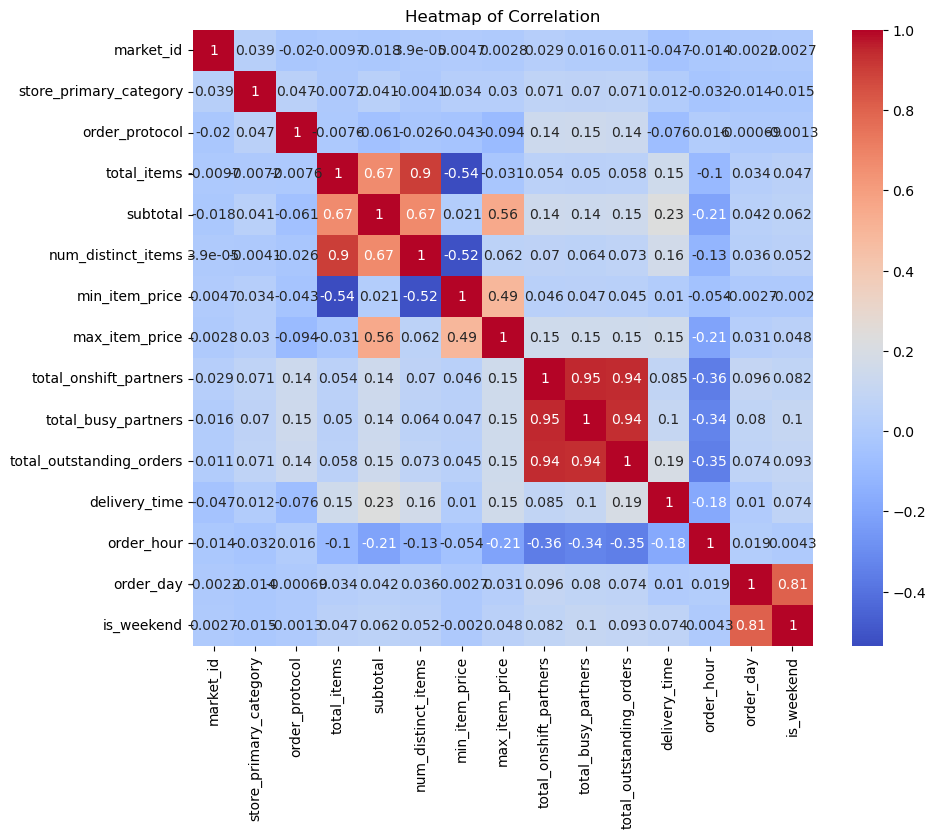

In [203]:
# Heatmap
corr = df.select_dtypes(include=['number']).corr() # numeric columns ka correlation
#corr
# Step 4: Heatmap plot karo
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")  # annot=True se values show hongi
plt.title("Heatmap of Correlation")
plt.show()

In [204]:
# Independent Variable->feature target->Dependent Variable
features = [
    'subtotal',
'total_items',
'num_distinct_items',
'max_item_price',
'total_onshift_partners',
'total_busy_partners',
'total_outstanding_orders',
'order_hour',
'is_weekend',
]

X = df[features]
y = df['delivery_time']

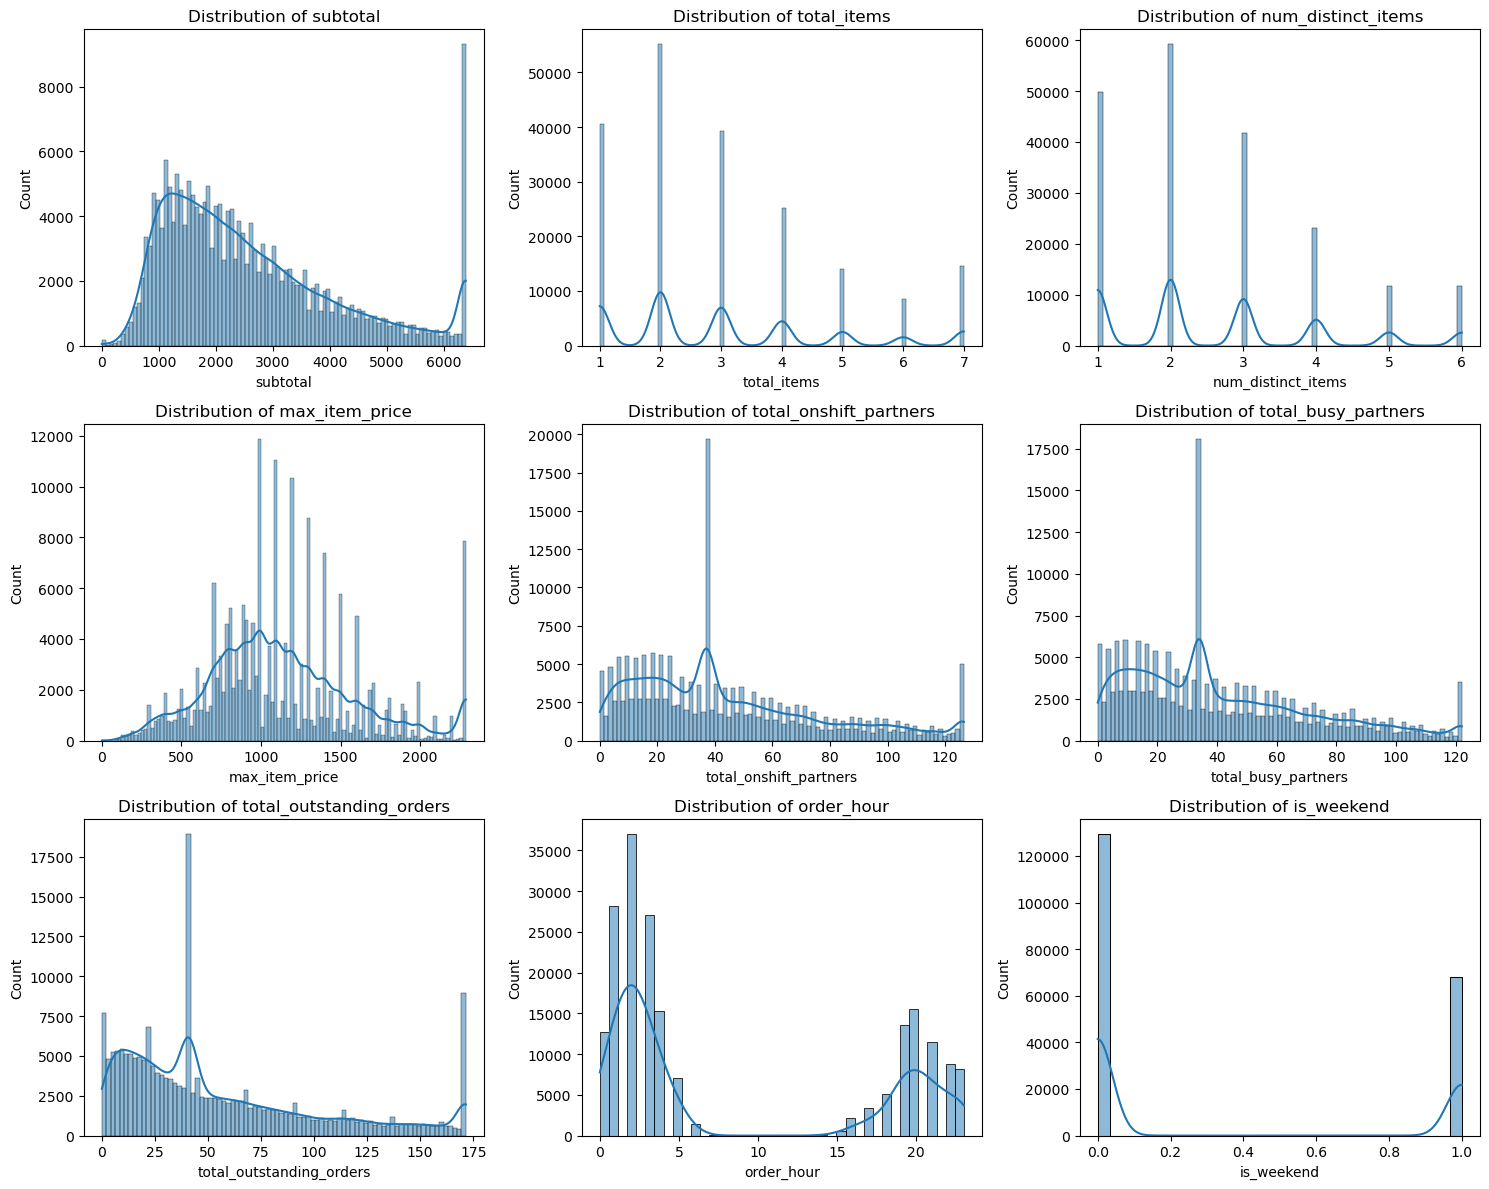

In [205]:
# Graph ka size set karo
plt.figure(figsize=(15, 12))

# Loop chalao har feature ke liye
for i, col in enumerate(features):
    plt.subplot(3, 3, i+1) # 3 rows, 3 columns ka grid
    sns.histplot(df[col], kde=True) # kde=True se curve bhi aata hai
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [206]:
#Train_test split 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(157936, 9)
(39485, 9)
(157936,)
(39485,)


In [207]:
#Standard Scaler
scaler=StandardScaler()
X_train_scale=scaler.fit_transform(X_train)
X_test_scale=scaler.transform(X_test)

In [208]:
# Ridge
model_ridge=Ridge()
model_ridge.fit(X_train_scale,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [209]:
# Prediction
y_pred_r = model_ridge.predict(X_test_scale)
print(y_pred_r)

[36.94830968 49.86414849 43.69793535 ... 69.01757012 41.81062667
 48.17955514]


In [210]:
# Eavalution metrics of Ridge
mae = mean_absolute_error(y_test, y_pred_r)
mse = mean_squared_error(y_test, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_r)  

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2) 

MAE: 11.550454861376227
MSE: 215.9784300469127
RMSE: 14.69620461367195
R2 Score: 0.18257547347874004


In [211]:
#GridSearchCV Ridge
# Parameters (hyperparameters)
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

# GridSearch
grid = GridSearchCV(model_ridge, param_grid, cv=5, scoring='r2')

# Train
grid.fit(X_train_scale, y_train)

# Best result
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)
# Best model use karo
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scale)
print("Test r2score:",  r2_score(y_test, y_pred))

Best Params: {'alpha': 1}
Best Score: 0.1827699983945641
Test r2score: 0.18257547347874004


In [212]:
#Ridge randomizedsearchCV
# Parameter distribution
param_dist = {
    'alpha': np.linspace(0.01, 100, 50)
}

# Random Search
random = RandomizedSearchCV(
    model_ridge,
    param_distributions=param_dist,
    n_iter=10,   # kitne random combinations try kare
    cv=5,
    scoring='r2',
    random_state=42
)

# Train
random.fit(X_train_scale, y_train)

# Best result
print("Best Params:", random.best_params_)
print("Best Score:", random.best_score_)

# Best model
best_model = random.best_estimator_

y_pred = best_model.predict(X_test_scale)
print("Test r2score", r2_score(y_test, y_pred))


Best Params: {'alpha': np.float64(26.53795918367347)}
Best Score: 0.18276890571954088
Test r2score 0.18258367521038965


In [213]:
#Lasso
lasso = Lasso()
lasso.fit(X_train_scale, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [214]:
# predict 
y_pred_lasso= lasso.predict(X_test_scale)
print(y_pred_lasso)

[44.34437837 49.16840599 42.89796092 ... 56.31426071 44.90408802
 45.61525423]


In [215]:
# Evalution metrics of Lasso 
mae = mean_absolute_error(y_test, y_pred_lasso)
mse = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lasso)  

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2) 

MAE: 12.31721740194482
MSE: 243.16312192170668
RMSE: 15.593688528430555
R2 Score: 0.0796881903386919


In [216]:
#Feature selection
print(lasso.coef_)

[ 2.34810548  0.          0.          0.         -0.         -0.
  1.40092108 -0.95864372  0.        ]


In [217]:
# Lasso RandomizedSearchCV
from scipy.stats import uniform
param_dist_lasso = {
    'alpha': uniform(0.01,10),             
    'max_iter': [1000, 5000, 10000],
    'selection': ['cyclic', 'random']
}
random_search = RandomizedSearchCV(
    estimator=lasso,
    param_distributions=param_dist_lasso,
    n_iter=10,                        
    scoring='r2', 
    cv=5,                             
    verbose=1,
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train_scale, y_train)
# Best model
best_model = random_search.best_estimator_
# Best result
print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)
y_pred = best_model.predict(X_test_scale)
print("Test r2score", r2_score(y_test, y_pred))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'alpha': np.float64(0.017787658410143285), 'max_iter': 1000, 'selection': 'cyclic'}
Best Score: 0.18272318423340012
Test r2score 0.1826431927064731


In [218]:
# lasso GridSearchCV
param_grid_lasso = {
    'alpha': [0.01,0.1,1,10],             
    'max_iter': [1000, 5000, 10000],
    'selection': ['cyclic', 'random']
}
grid_search = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid_lasso,                        
    scoring='r2', 
    cv=5,                             
    verbose=1,
    n_jobs=-1,
)
grid_search.fit(X_train_scale, y_train)
# Best model
best_model = grid_search.best_estimator_
# Best result
print("Best Params:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
y_pred = best_model.predict(X_test_scale)
print("Test r2score", r2_score(y_test, y_pred))



Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'alpha': 0.01, 'max_iter': 1000, 'selection': 'cyclic'}
Best Score: 0.1827572996099584
Test r2score 0.18262445184506992


In [219]:
#Multiple linear Regr"essor
model_lr = LinearRegression()
model_lr.fit(X_train_scale, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [220]:
y_pred_lr = model_lr.predict(X_test_scale)
print(y_pred_lr[:10]) 

[36.94780892 49.8639993  43.6982589  33.57189709 45.52146979 39.3868565
 52.55664072 41.12150746 45.06969263 44.20158367]


In [221]:
# X coeeficient 
print(model_lr.coef_[0]) #slop
# y intercept
print(model_lr.intercept_)

2.2954890083091115
47.03808238780265


In [222]:
# Evalution matrics of M-Linear regressoion
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)  

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2) 

MAE: 11.550456470006305
MSE: 215.97852371689189
RMSE: 14.696207800548136
R2 Score: 0.18257511896121548


In [223]:
# Linear Regression actaul vs predict
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lr
})

results.head() 

,Actual,Predicted
188418,31.88,36.947809
29851,52.42,49.863999
194087,33.85,43.698259
82297,36.80,33.571897
52753,34.82,45.521470


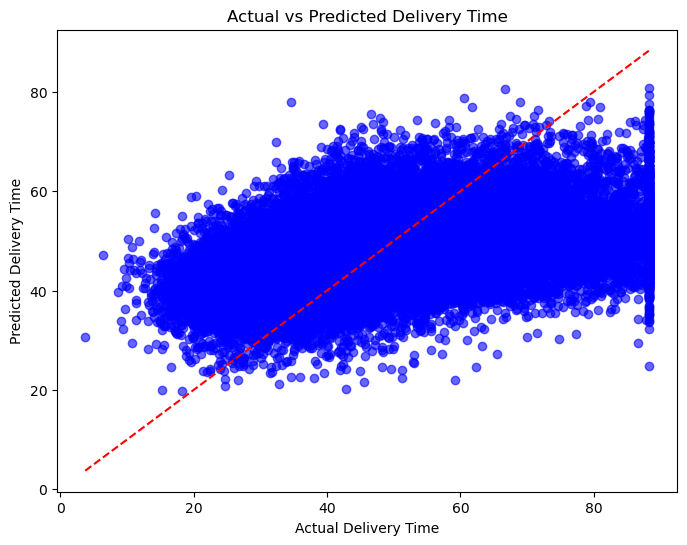

In [224]:
# Actual vs predict graph of linear Regression
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect fit line
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

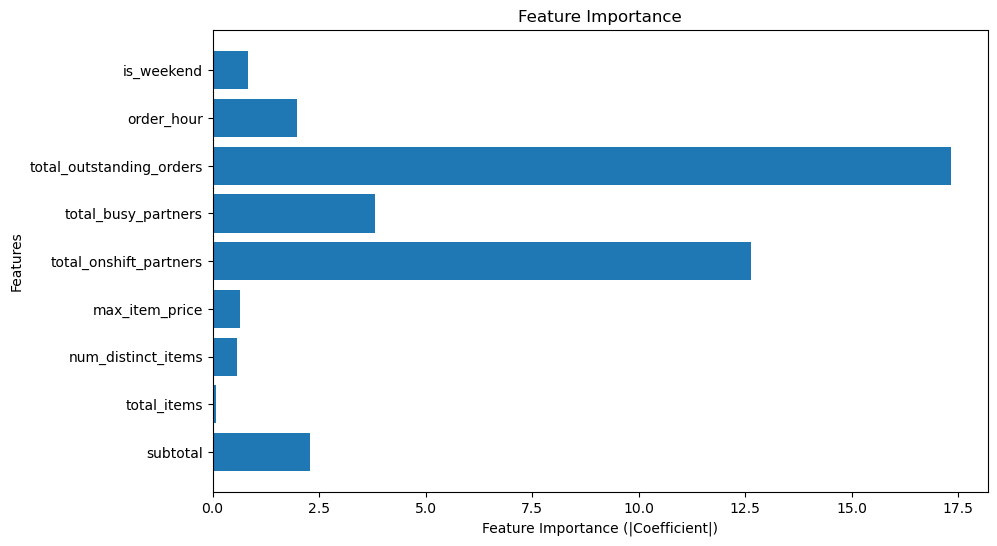

In [225]:
# feature importance  for linear regression
importance = abs(model_lr.coef_)
# phir graph banao
plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.xlabel("Feature Importance (|Coefficient|)")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

In [226]:
#Random Forest Regressor
model_rf = RandomForestRegressor()
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [227]:
y_pred = model_rf.predict(X_test)
print(y_pred[:10])

[41.3006   54.6205   55.6726   38.1716   47.516525 47.0915   63.1658
 39.0084   64.82     48.2169  ]


In [228]:
# Evalution matrics of Random forest regressor
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)  

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2) 

MAE: 11.280125012925195
MSE: 207.98212654007824
RMSE: 14.42158543781086
R2 Score: 0.2128394892259361


In [229]:
# Random Forest Regression Actual vs predict
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
results.head() 

,Actual,Predicted
188418,31.88,41.300600
29851,52.42,54.620500
194087,33.85,55.672600
82297,36.80,38.171600
52753,34.82,47.516525


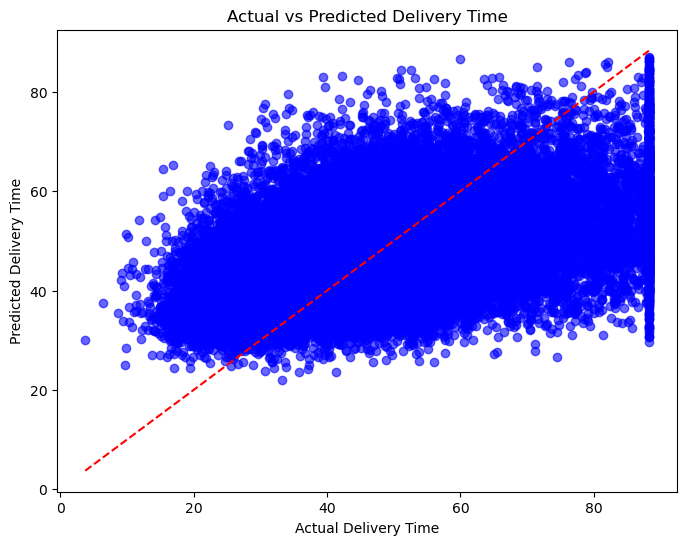

In [230]:
# Actual vs predict graph for Random Forest Regressor
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect fit line
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

In [231]:
imp = pd.Series(model_rf.feature_importances_, index=X.columns)
print(imp.sort_values(ascending=False))

subtotal                    0.221458
max_item_price              0.174685
total_outstanding_orders    0.151685
total_onshift_partners      0.137849
order_hour                  0.117394
total_busy_partners         0.094470
num_distinct_items          0.038318
total_items                 0.038228
is_weekend                  0.025914
dtype: float64


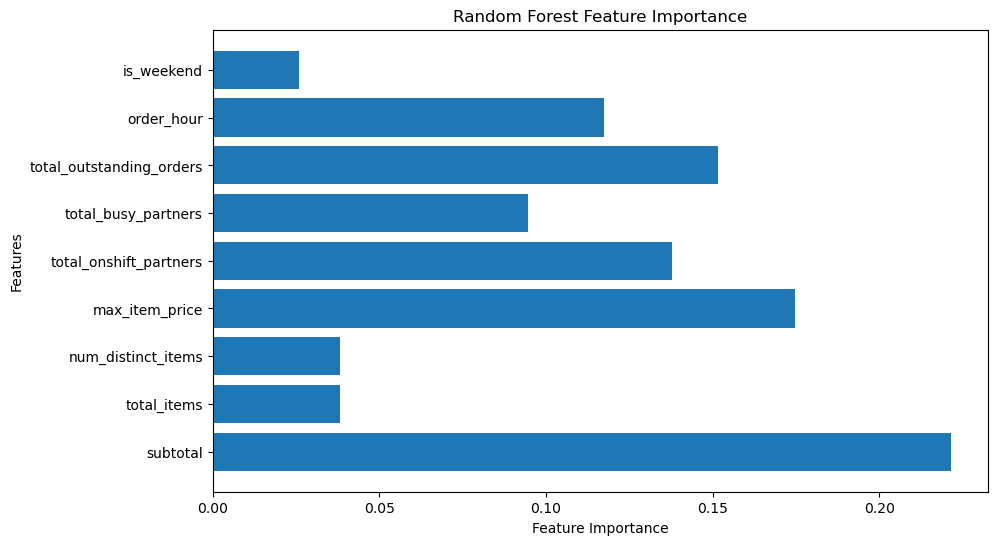

In [232]:
# feature importance  of Random Forest Regressor
importance = model_rf.feature_importances_
# Plot
plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()


In [233]:

# Linear Regression importance
lr_importance = abs(model_lr.coef_)

# Random Forest importance
rf_importance = model_rf.feature_importances_

# Combine into DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Linear': lr_importance,
    'RandomForest': rf_importance
})

print(importance_df)

                    Feature     Linear  RandomForest
0                  subtotal   2.295489      0.221458
1               total_items   0.081249      0.038228
2        num_distinct_items   0.565848      0.038318
3            max_item_price   0.634381      0.174685
4    total_onshift_partners  12.632705      0.137849
5       total_busy_partners   3.808099      0.094470
6  total_outstanding_orders  17.323979      0.151685
7                order_hour   1.968833      0.117394
8                is_weekend   0.820263      0.025914


In [234]:
# lr tunning grid search


In [235]:
# lr tunning using Randomized search cv


In [236]:
# # # # random forest grid search cv
# param_grid = {
#     'n_estimators': [100,200],
#     'max_depth': [10,20],
#     'min_samples_split': [2,5],
#     'min_samples_leaf': [1,2]
# }

# grid_search = GridSearchCV(
#     estimator=model_rf,
#     param_grid=param_grid,
#     cv=5,
#     n_jobs=1
# )

# grid_search.fit(X_train, y_train)
# best_model_rf = grid.best_estimator_

# print("Best Parameters:", grid_search.best_params_)
# print("best score:",grid_search.best_score_)
# y_pred_rf = best_model_rf.predict(X_test)
# print("Actual R2:", r2_score(y_test, y_pred_rf))

In [237]:
# #random forest randomized search cv
# param_dist = {
#     'n_estimators': [100,200],
#     'max_depth': [10,20],
#     'min_samples_split': [2,5],
#     'max_features':['sqrt','log2']
# }

# random_search = RandomizedSearchCV(
#     estimator=model_rf,
#     param_distributions=param_dist,
#     n_iter=10,
#     cv=3,
#     random_state=42,
#     n_jobs=-1
# )

# random_search.fit(X_train, y_train)
# best_model_rf = grid.best_estimator_

# print("Best Parameters:", random_search.best_params_)
# print("best score:",random_search.best_score_)
# y_pred_rf = best_model_rf.predict(X_test)
# print("Actual R2:", r2_score(y_test, y_pred_rf))


In [238]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [239]:
from xgboost import XGBRegressor
model_x=XGBRegressor()
model_x.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [240]:
xg_predict=model_x.predict(X_test)
print(xg_predict)

[34.115524 54.43588  49.20815  ... 64.6785   40.65463  56.049915]


In [241]:
# Evalution matrics of XGBregressor
mae = mean_absolute_error(y_test, xg_predict)
mse = mean_squared_error(y_test, xg_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,xg_predict)  

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2) 

MAE: 10.914325969230863
MSE: 194.99561901843694
RMSE: 13.96408317858487
R2 Score: 0.26199018339357416


In [242]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": xg_predict
})
results.head() 

,Actual,Predicted
188418,31.88,34.115524
29851,52.42,54.435879
194087,33.85,49.208149
82297,36.80,35.974228
52753,34.82,43.787289


Text(0.5, 1.0, 'XGBoost Feature Importance')

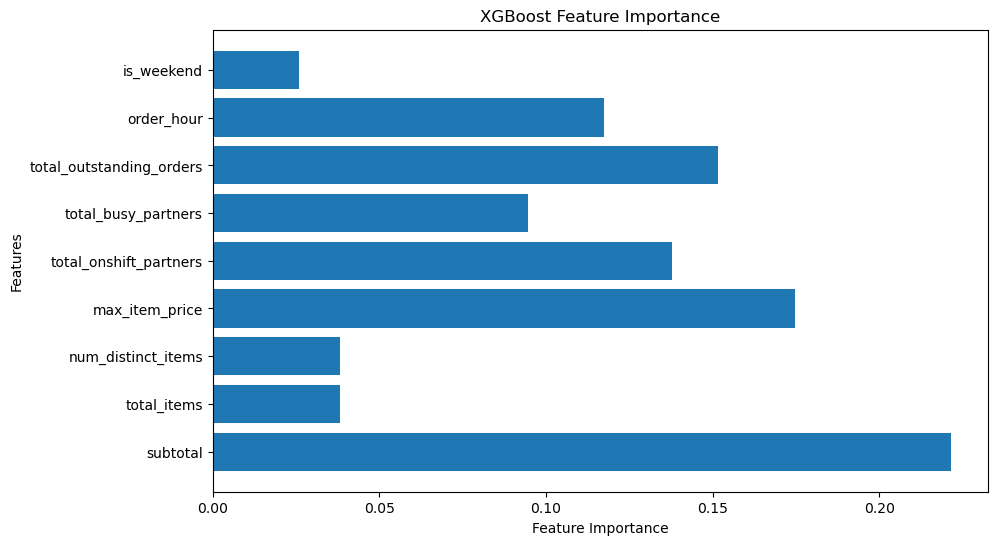

In [243]:
# importance = model_x.feature_importances_

# # Plot
plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")

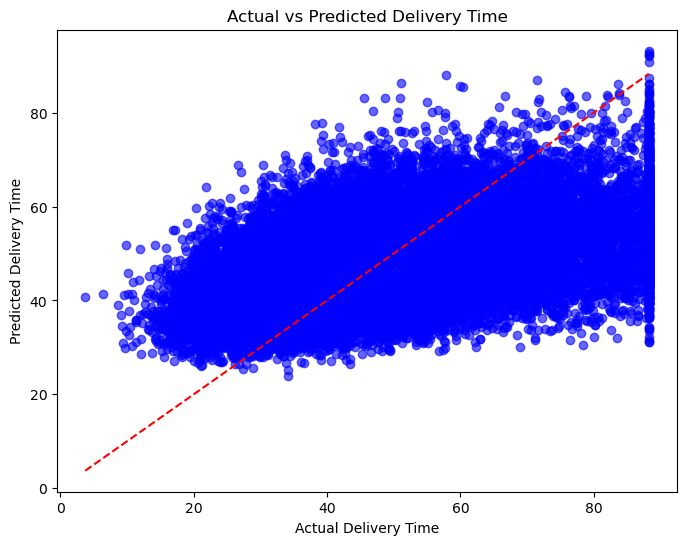

In [244]:
#Actual vs predict graph for XGBoost Regressor
plt.figure(figsize=(8,6))
plt.scatter(y_test, xg_predict, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect fit line
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

In [245]:
#GridSearchCV OF XGBregreesor
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=model_x,
    param_grid=param_grid,
    cv=3,
    scoring='r2'
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("best score:",grid.best_score_)
print(grid.scoring)
y_pred_xg = best_model.predict(X_test)
print("Actual R2:", r2_score(y_test, y_pred_xg))

joblib.dump(best_model, "model_xgb.pkl")

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
best score: 0.26759248812259373
r2
Actual R2: 0.26627409845236916


['model_xgb.pkl']

In [246]:
#Randmized SearchCV of XGBregressor
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1]
}
random = RandomizedSearchCV(
    estimator=model_x,
    param_distributions=param_dist,
    n_iter=10,   # kitne combinations try kare
    cv=3,
    scoring='r2',
    random_state=42
)

random.fit(X_train, y_train)
best_model = random.best_estimator_
print("Best Parameters:", random.best_params_)
print("best score:",random.best_score_)
y_pred_xg = best_model.predict(X_test)
print("Actual R2:", r2_score(y_test, y_pred_xg))

Best Parameters: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}
best score: 0.26759248812259373
Actual R2: 0.26627409845236916


In [247]:
# Ensemble Prediction(Average)
final_pred=(y_pred_lr+y_pred+xg_predict)/3
print("Ensemble predictions (Avg):",final_pred)


Ensemble predictions (Avg): [37.4546444  52.97345935 49.52633595 ... 67.48777806 41.40699616
 53.53343944]


<function matplotlib.pyplot.show(close=None, block=None)>

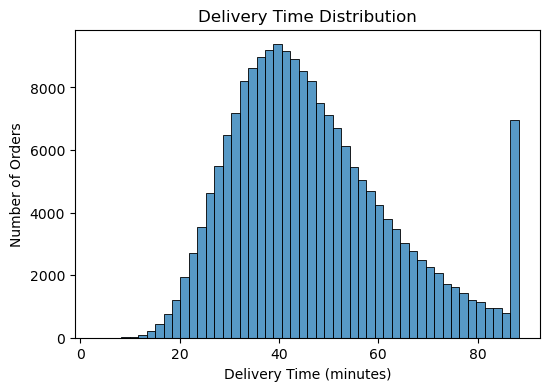

In [248]:
#Histogram (Delivery Time Distribution)
plt.figure(figsize=(6,4))
sns.histplot(df['delivery_time'], bins=50)
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.show

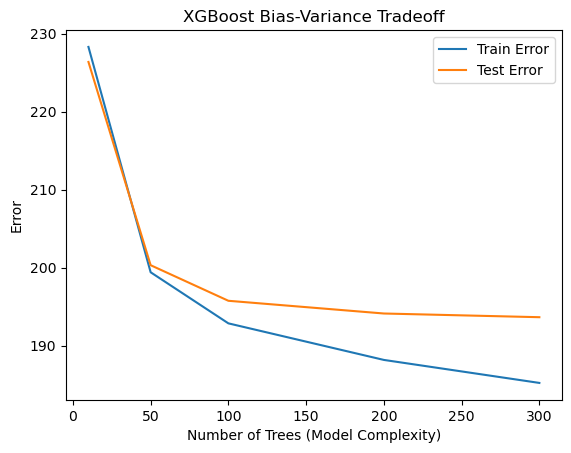

In [249]:
# Bias and Variance graph for XGBR
train_errors = []
test_errors = []

# complexity control (trees)
n_estimators_range = [10, 50, 100, 200, 300]

for n in n_estimators_range:
    model = XGBRegressor(
        n_estimators=n,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# Plot
plt.figure()

plt.plot(n_estimators_range, train_errors, label="Train Error")
plt.plot(n_estimators_range, test_errors, label="Test Error")

plt.xlabel("Number of Trees (Model Complexity)")
plt.ylabel("Error")
plt.title("XGBoost Bias-Variance Tradeoff")

plt.legend()
plt.show()


In [250]:

# ---------------- Cleaning ----------------
def clean_dataframe(df):
    # remove special characters
    for col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(r'[^0-9.]', '', regex=True)
            .str.strip()
        )

    # convert to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # handle NaN & infinity
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

    return df

# ---------------- Generate New Data ----------------
def generate_new_data():
    data = {
        "subtotal": ["###"],                  # test case (special char)
        "total_items": ["5"],
        "num_distinct_items": ["3"],
        "max_item_price": ["50"],
        "total_onshift_partners": ["20"],
        "total_busy_partners": ["-5"],
        "total_outstanding_orders": ["10"],
        "order_hour": ["14"],
        "is_weekend": ["1"]
    }

    return pd.DataFrame(data)

# ---------------- Prediction ----------------
def predict():
    df = generate_new_data()

    print("🔹 Raw Data:\n", df)

    # cleaning (VERY IMPORTANT)
    df = clean_dataframe(df)

    print("\n🔹 Cleaned Data:\n", df)

    # prediction
    prediction = model.predict(df)

    print("\n🚚 Predicted Delivery Time:", prediction[0], "minutes")

# ---------------- Run ----------------
if __name__ == "__main__":
    predict() 

🔹 Raw Data:
   subtotal total_items num_distinct_items max_item_price  \
0      ###           5                  3             50   

  total_onshift_partners total_busy_partners total_outstanding_orders  \
0                     20                  -5                       10   

  order_hour is_weekend  
0         14          1  

🔹 Cleaned Data:
    subtotal  total_items  num_distinct_items  max_item_price  \
0       0.0            5                   3              50   

   total_onshift_partners  total_busy_partners  total_outstanding_orders  \
0                      20                    5                        10   

   order_hour  is_weekend  
0          14           1  

🚚 Predicted Delivery Time: 36.88715 minutes


In [251]:
# ---------------- Cleaning ----------------
def clean_dataframe(df):
    # remove special characters
    for col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(r'[^0-9.]', '', regex=True)
            .str.strip()
        )

    # convert to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # handle NaN & infinity
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

    return df

# ---------------- Generate New Data ----------------
def generate_new_data():
    data = {
        "subtotal": ["$120.50"],                  # test case (special char)
        "total_items": ["-5 items"],
        "num_distinct_items": ["N/A"],
        "max_item_price": ["@#$%"],
        "total_onshift_partners": ["20"],
        "total_busy_partners": ["5"],
        "total_outstanding_orders": ["Inf"],
        "order_hour": ["14"],
        "is_weekend": ["Yes"]
    }

    return pd.DataFrame(data)

# ---------------- Prediction ----------------
def predict():
    df = generate_new_data()

    print("Raw Data:\n", df)

    # cleaning (VERY IMPORTANT)
    df = clean_dataframe(df)

    print("\n Cleaned Data:\n", df)

    # prediction
    prediction = model.predict(df)

    print("\n Predicted Delivery Time:", prediction[0], "minutes")

# ---------------- Run ----------------
if __name__ == "__main__":
    predict()

Raw Data:
   subtotal total_items num_distinct_items max_item_price  \
0  $120.50    -5 items                N/A           @#$%   

  total_onshift_partners total_busy_partners total_outstanding_orders  \
0                     20                   5                      Inf   

  order_hour is_weekend  
0         14        Yes  

 Cleaned Data:
    subtotal  total_items  num_distinct_items  max_item_price  \
0     120.5            5                 0.0             0.0   

   total_onshift_partners  total_busy_partners  total_outstanding_orders  \
0                      20                    5                       0.0   

   order_hour  is_weekend  
0          14         0.0  

 Predicted Delivery Time: 32.508606 minutes
